# EDA - Intel Image Classification

Este notebook describe el dataset de escenas naturales usado en el proyecto antes del modelamiento.

El analisis responde cuatro preguntas:

1. Que particiones y clases estan disponibles.
2. Que tan balanceadas estan las clases etiquetadas.
3. Que variacion visual y de resolucion tienen las imagenes.
4. Que senales de calidad o posible fuga de datos deben revisarse antes de entrenar.

## Contexto del dataset

La descarga local contiene imagenes `.jpg` de seis categorias: `buildings`, `forest`, `glacier`, `mountain`, `sea` y `street`.

- `seg_train` y `seg_test` estan etiquetados y permiten comparar distribuciones por clase.
- `seg_test` es la particion de prueba: sus etiquetas representan la referencia real que se compara con `y_pred` al evaluar un modelo.
- `seg_pred` no trae etiquetas. En este EDA se mostrara como `inference` para no confundir esa carpeta con `y_pred`; sirve para generar predicciones, no para calcular metricas supervisadas.
- La revision de duplicados exactos entre `train` y `test` busca detectar copias que puedan sesgar la evaluacion.

## Configuracion y rutas

El dataset se descarga en `data/` mediante `main.py`. Las rutas se resuelven desde el repo para que el notebook funcione al abrirse desde la raiz o desde `notebooks/`.

In [13]:
from hashlib import sha1
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

SEED = 42
RNG = np.random.default_rng(SEED)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

In [14]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("No se encontro pyproject.toml al resolver la raiz del proyecto.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data"
DATASET_PATHS = {
    "train": DATA_PATH / "seg_train" / "seg_train",
    "test": DATA_PATH / "seg_test" / "seg_test",
    "inference": DATA_PATH / "seg_pred" / "seg_pred",
}

missing_paths = [str(path) for path in DATASET_PATHS.values() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Faltan carpetas del dataset. Ejecuta `uv run python main.py` desde la raiz del repo. "
        f"Rutas esperadas: {missing_paths}"
    )

DATASET_PATHS

{'train': WindowsPath('C:/especializacion IA/machine learning/trabajo final/aprendizaje-maquinas-trabajo-final/data/seg_train/seg_train'),
 'test': WindowsPath('C:/especializacion IA/machine learning/trabajo final/aprendizaje-maquinas-trabajo-final/data/seg_test/seg_test'),
 'inference': WindowsPath('C:/especializacion IA/machine learning/trabajo final/aprendizaje-maquinas-trabajo-final/data/seg_pred/seg_pred')}

## Inventario del dataset

Primero se construye un inventario por archivo. Esta tabla separa las particiones etiquetadas de la particion no etiquetada y sirve como base para los analisis siguientes.

In [15]:
def image_files(path: Path) -> list[Path]:
    return sorted(
        file_path
        for file_path in path.rglob("*")
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )


def build_inventory(dataset_paths: dict[str, Path]) -> pd.DataFrame:
    records = []
    for split, split_path in dataset_paths.items():
        for file_path in image_files(split_path):
            label = file_path.parent.name if split != "inference" else "unlabeled"
            records.append({
                "split": split,
                "label": label,
                "path": file_path,
                "extension": file_path.suffix.lower(),
                "file_size_kb": file_path.stat().st_size / 1024,
            })
    return pd.DataFrame(records)


inventory_df = build_inventory(DATASET_PATHS)
inventory_df.head()

,split,label,path,extension,file_size_kb
0,train,buildings,C:\especializacion IA\machine learning\trabajo...,.jpg,10.829102
1,train,buildings,C:\especializacion IA\machine learning\trabajo...,.jpg,16.408203
2,train,buildings,C:\especializacion IA\machine learning\trabajo...,.jpg,16.473633
3,train,buildings,C:\especializacion IA\machine learning\trabajo...,.jpg,17.122070
4,train,buildings,C:\especializacion IA\machine learning\trabajo...,.jpg,12.022461


In [16]:
overview_df = (
    inventory_df.groupby("split", observed=True)
    .agg(
        images=("path", "size"),
        labels=("label", "nunique"),
        mean_file_size_kb=("file_size_kb", "mean"),
        median_file_size_kb=("file_size_kb", "median"),
    )
    .round(2)
)

display(Markdown("### Resumen de particiones"))
display(overview_df)
display(Markdown("### Formatos encontrados"))
display(pd.crosstab(inventory_df["split"], inventory_df["extension"]))

### Resumen de particiones

,images,labels,mean_file_size_kb,median_file_size_kb
split,,,,
inference,7301,1,14.79,14.66
test,3000,6,14.77,14.64
train,14034,6,14.81,14.68


### Formatos encontrados

extension,.jpg
split,
inference,7301
test,3000
train,14034


In [17]:
labeled_images = int(inventory_df[inventory_df["split"].isin(["train", "test"])].shape[0])
inference_images = int((inventory_df["split"] == "inference").sum())
known_labels = sorted(inventory_df.loc[inventory_df["split"] == "train", "label"].unique())

display(Markdown(
    f"**Lectura inicial:** hay {labeled_images:,} imagenes etiquetadas para analisis supervisado "
    f"y {inference_images:,} imagenes sin etiqueta en `inference` (carpeta original `seg_pred`). "
    f"Las clases etiquetadas son: {', '.join(known_labels)}."
))

**Lectura inicial:** hay 17,034 imagenes etiquetadas para analisis supervisado y 7,301 imagenes sin etiqueta en `inference` (carpeta original `seg_pred`). Las clases etiquetadas son: buildings, forest, glacier, mountain, sea, street.

## Balance de clases

Se compara la representacion de cada clase en las particiones etiquetadas para ver si `train` y `test` mantienen coberturas similares por categoria.

In [18]:
labeled_df = inventory_df[inventory_df["split"].isin(["train", "test"])].copy()
class_counts_df = (
    labeled_df.groupby(["label", "split"], observed=True)
    .size()
    .rename("images")
    .reset_index()
)

class_share_df = class_counts_df.copy()
class_share_df["share"] = class_share_df["images"] / class_share_df.groupby("split")["images"].transform("sum")

display(class_counts_df.pivot(index="label", columns="split", values="images").fillna(0).astype(int))
display(class_share_df.pivot(index="label", columns="split", values="share").fillna(0).round(3))

split,test,train
label,,
buildings,437,2191
forest,474,2271
glacier,553,2404
mountain,525,2512
sea,510,2274
street,501,2382


split,test,train
label,,
buildings,0.146,0.156
forest,0.158,0.162
glacier,0.184,0.171
mountain,0.175,0.179
sea,0.170,0.162
street,0.167,0.170


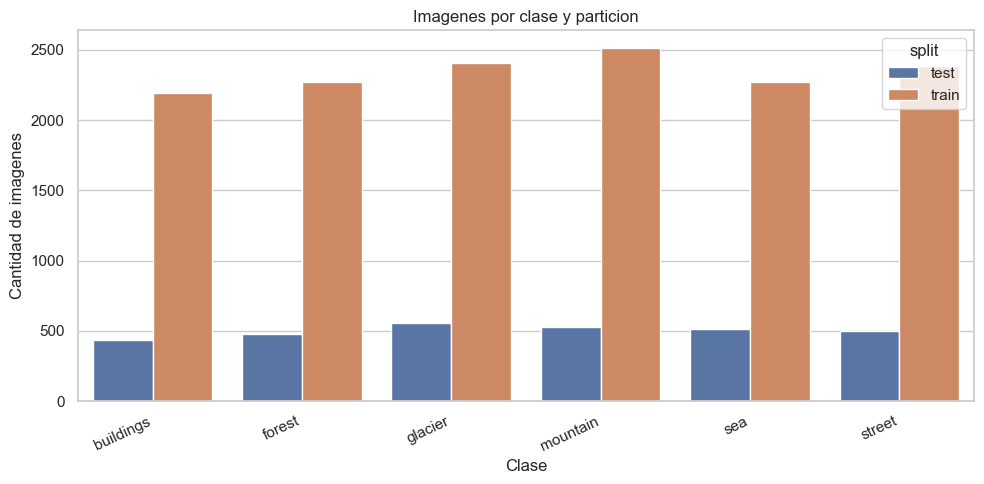

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=class_counts_df, x="label", y="images", hue="split")
plt.title("Imagenes por clase y particion")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imagenes")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Muestras visuales

Una muestra por clase permite revisar de forma cualitativa la variacion de perspectiva, iluminacion y contenido dentro de cada etiqueta.

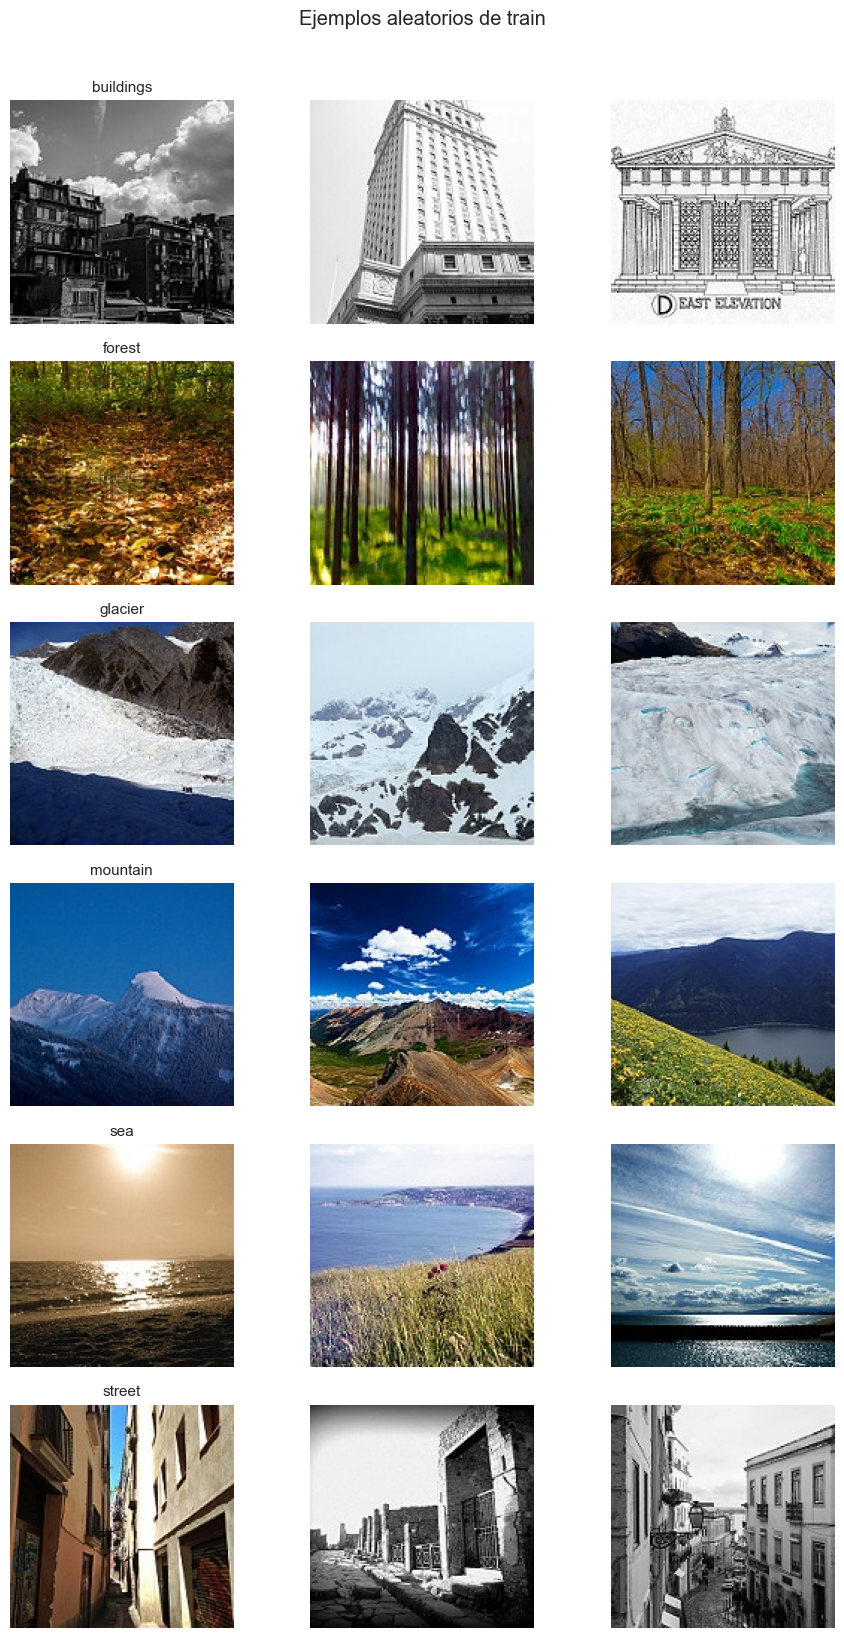

In [20]:
def read_rgb(path: Path) -> np.ndarray | None:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        return None
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def plot_class_examples(dataframe: pd.DataFrame, split: str, examples_per_class: int = 3) -> None:
    split_df = dataframe[dataframe["split"] == split]
    labels = sorted(split_df["label"].unique())
    fig, axes = plt.subplots(len(labels), examples_per_class, figsize=(3.2 * examples_per_class, 2.7 * len(labels)))
    axes = np.atleast_2d(axes)

    for row, label in enumerate(labels):
        label_paths = split_df.loc[split_df["label"] == label, "path"].to_numpy()
        sample_size = min(examples_per_class, len(label_paths))
        selected_paths = RNG.choice(label_paths, size=sample_size, replace=False)

        for column in range(examples_per_class):
            axis = axes[row, column]
            axis.axis("off")
            if column >= sample_size:
                continue
            image = read_rgb(Path(selected_paths[column]))
            if image is not None:
                axis.imshow(image)
            axis.set_title(label if column == 0 else "", fontsize=11)

    fig.suptitle(f"Ejemplos aleatorios de {split}", y=1.01)
    plt.tight_layout()
    plt.show()


plot_class_examples(inventory_df, split="train", examples_per_class=3)

## Calidad y dimensiones

Se leen las imagenes para detectar archivos ilegibles y describir sus dimensiones. El notebook de modelos usa entradas de `150 x 150`; este bloque muestra la variacion que ese preprocesamiento debe normalizar.

In [21]:
def inspect_image(path: Path) -> dict[str, float | int | bool]:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        return {"readable": False, "height": np.nan, "width": np.nan, "channels": np.nan, "mean_intensity": np.nan}

    height, width, channels = image.shape
    return {
        "readable": True,
        "height": height,
        "width": width,
        "channels": channels,
        "mean_intensity": float(image.mean()),
    }


image_metadata_df = inventory_df["path"].apply(inspect_image).apply(pd.Series)
eda_df = pd.concat([inventory_df.reset_index(drop=True), image_metadata_df], axis=1)
eda_df["aspect_ratio"] = eda_df["width"] / eda_df["height"]

quality_summary_df = (
    eda_df.groupby("split", observed=True)
    .agg(
        images=("path", "size"),
        unreadable=("readable", lambda values: int((~values.astype(bool)).sum())),
        min_height=("height", "min"),
        median_height=("height", "median"),
        max_height=("height", "max"),
        min_width=("width", "min"),
        median_width=("width", "median"),
        max_width=("width", "max"),
    )
)

display(quality_summary_df.round(2))
display(eda_df.loc[~eda_df["readable"], ["split", "label", "path"]])

,images,unreadable,min_height,median_height,max_height,min_width,median_width,max_width
split,,,,,,,,
inference,7301,0,100,150.0,374,150,150.0,500
test,3000,0,72,150.0,150,150,150.0,150
train,14034,0,76,150.0,150,150,150.0,150


,split,label,path


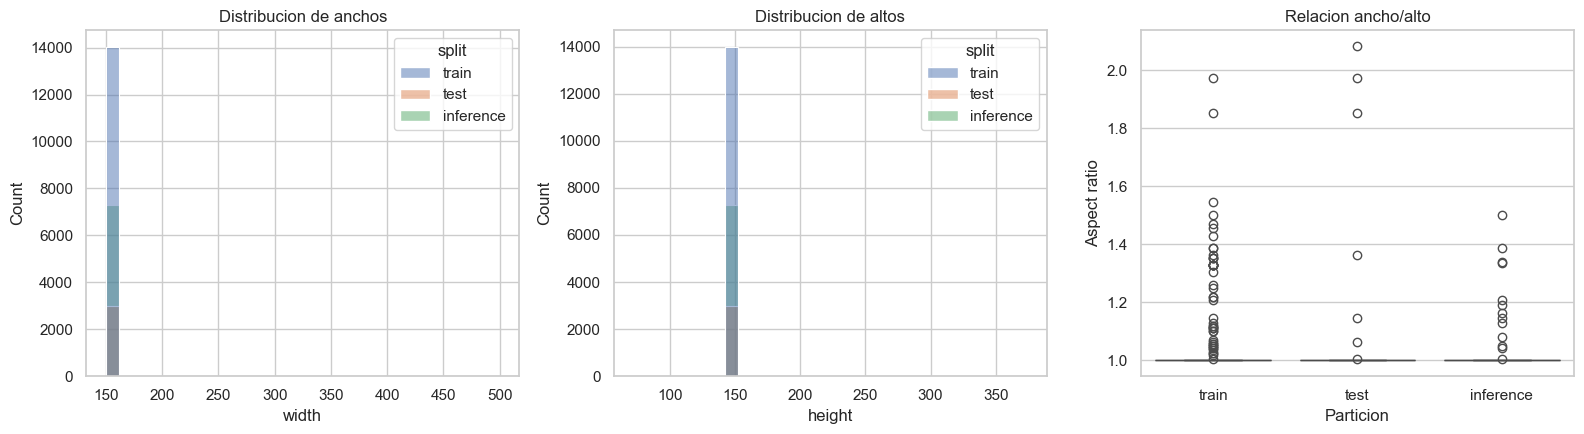

In [22]:
readable_df = eda_df[eda_df["readable"]].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(data=readable_df, x="width", hue="split", bins=30, ax=axes[0])
axes[0].set_title("Distribucion de anchos")
sns.histplot(data=readable_df, x="height", hue="split", bins=30, ax=axes[1])
axes[1].set_title("Distribucion de altos")
sns.boxplot(data=readable_df, x="split", y="aspect_ratio", ax=axes[2])
axes[2].set_title("Relacion ancho/alto")
axes[2].set_xlabel("Particion")
axes[2].set_ylabel("Aspect ratio")
plt.tight_layout()
plt.show()

## Duplicados exactos

Los hashes exactos permiten detectar copias byte a byte. El foco esta en `train` y `test`, porque una copia compartida entre ambas particiones puede introducir fuga de informacion.

In [23]:
def file_sha1(path: Path) -> str:
    digest = sha1()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


labeled_hash_df = eda_df[eda_df["split"].isin(["train", "test"])].copy()
labeled_hash_df["sha1"] = labeled_hash_df["path"].apply(file_sha1)
duplicate_groups_df = (
    labeled_hash_df.groupby("sha1", observed=True)
    .agg(
        copies=("path", "size"),
        splits=("split", lambda values: sorted(set(values))),
        labels=("label", lambda values: sorted(set(values))),
        paths=("path", lambda values: list(values)),
    )
    .query("copies > 1")
    .sort_values("copies", ascending=False)
)

cross_split_duplicates_df = duplicate_groups_df[
    duplicate_groups_df["splits"].apply(lambda splits: {"train", "test"}.issubset(set(splits)))
]
label_conflict_duplicates_df = cross_split_duplicates_df[
    cross_split_duplicates_df["labels"].apply(lambda labels: len(labels) > 1)
]

print(f"Grupos duplicados exactos en train/test: {len(duplicate_groups_df)}")
print(f"Duplicados exactos que cruzan train/test: {len(cross_split_duplicates_df)}")
print(f"Duplicados train/test con etiquetas distintas: {len(label_conflict_duplicates_df)}")
display(cross_split_duplicates_df.head(10))

Grupos duplicados exactos en train/test: 18
Duplicados exactos que cruzan train/test: 3
Duplicados train/test con etiquetas distintas: 3


,copies,splits,labels,paths
sha1,,,,
30e2a7bbdf76c53851df1677b76c976f8fe9324b,2,"[test, train]","[glacier, mountain]",[C:\especializacion IA\machine learning\trabaj...
790b6d97353df4ba7b1a36f0de9356633d3ad5ee,2,"[test, train]","[buildings, street]",[C:\especializacion IA\machine learning\trabaj...
e4fe1c3f3efd2210290c461c53f641af123e4f7a,2,"[test, train]","[buildings, street]",[C:\especializacion IA\machine learning\trabaj...


In [24]:
train_counts = class_counts_df[class_counts_df["split"] == "train"].set_index("label")["images"]
test_counts = class_counts_df[class_counts_df["split"] == "test"].set_index("label")["images"]
unreadable_images = int((~eda_df["readable"].astype(bool)).sum())
min_height = int(readable_df["height"].min())
max_height = int(readable_df["height"].max())
min_width = int(readable_df["width"].min())
max_width = int(readable_df["width"].max())

summary_text = f"""
## Conclusiones del EDA

- La descarga contiene **{len(inventory_df):,} imagenes**: **{int((inventory_df['split'] == 'train').sum()):,}** en `train`, **{int((inventory_df['split'] == 'test').sum()):,}** en `test` y **{int((inventory_df['split'] == 'inference').sum()):,}** en `inference` (carpeta original `seg_pred`).
- Las particiones etiquetadas cubren **{len(known_labels)} clases**. El rango de imagenes por clase es **{int(train_counts.min()):,}** a **{int(train_counts.max()):,}** en `train` y **{int(test_counts.min()):,}** a **{int(test_counts.max()):,}** en `test`.
- La lectura de archivos encontro **{unreadable_images} imagenes ilegibles**. Entre las imagenes legibles, las dimensiones observadas van de **{min_width} x {min_height}** a **{max_width} x {max_height}**; el pipeline debe aplicar un preprocesamiento consistente antes de alimentar los modelos.
- El chequeo de hashes detecto **{len(duplicate_groups_df)} grupos de duplicados exactos** dentro de `train/test`; **{len(cross_split_duplicates_df)}** cruzan ambas particiones y **{len(label_conflict_duplicates_df)}** de esos cruces tienen etiquetas distintas. Los cruces `train`/`test` deben revisarse antes de interpretar metricas finales.
- `inference` no tiene etiquetas y queda fuera de accuracy, matriz de confusion y reporte de clasificacion. Las predicciones calculadas por un modelo se nombran aparte, por ejemplo `y_pred`.
"""

display(Markdown(summary_text))


## Conclusiones del EDA

- La descarga contiene **24,335 imagenes**: **14,034** en `train`, **3,000** en `test` y **7,301** en `inference` (carpeta original `seg_pred`).
- Las particiones etiquetadas cubren **6 clases**. El rango de imagenes por clase es **2,191** a **2,512** en `train` y **437** a **553** en `test`.
- La lectura de archivos encontro **0 imagenes ilegibles**. Entre las imagenes legibles, las dimensiones observadas van de **150 x 72** a **500 x 374**; el pipeline debe aplicar un preprocesamiento consistente antes de alimentar los modelos.
- El chequeo de hashes detecto **18 grupos de duplicados exactos** dentro de `train/test`; **3** cruzan ambas particiones y **3** de esos cruces tienen etiquetas distintas. Los cruces `train`/`test` deben revisarse antes de interpretar metricas finales.
- `inference` no tiene etiquetas y queda fuera de accuracy, matriz de confusion y reporte de clasificacion. Las predicciones calculadas por un modelo se nombran aparte, por ejemplo `y_pred`.
